In [1]:
import corner
import matplotlib.pyplot as pl
import numpy as np
import os
from astropy.io import fits 

indir = '/home/ubuntu/work/lcretrieval/results/HD209458b/results-260507-joint/'
infile  = os.path.join(indir, 'HD209458b.fits')

with fits.open(infile) as hdul:
    header = hdul['MCMC'].header
    data = hdul['MCMC'].data
    postsamples = np.column_stack([data[name] for name in data.dtype.names])
    pnames = [name for name in data.dtype.names]


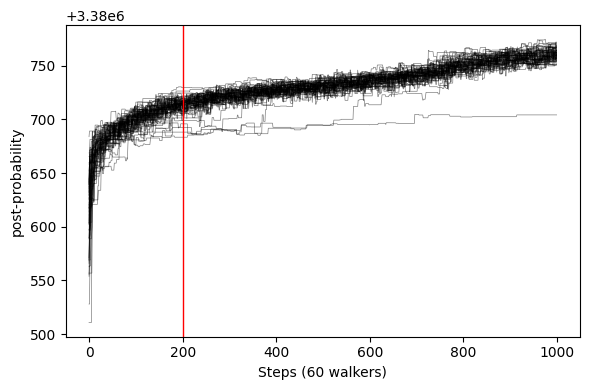

In [2]:
infile = indir + 'lnprob.txt'
burnin = 200

lnprobs = np.loadtxt(infile)
maxlike_params = postsamples[lnprobs.flatten().argmax()] 

fig, ax = pl.subplots(1,1,figsize=(6,4))
ax.plot(lnprobs, c='k', lw=0.5, alpha=0.5)
ax.axvline(burnin, c='r', lw=1)
ax.set_xlabel(f'Steps ({lnprobs.shape[1]} walkers)')
ax.set_ylabel('post-probability')
fig.tight_layout()

In [5]:
# s = postsamples[np.where(lnprobs.flatten() > 84827740)[0]]
s = postsamples[lnprobs.shape[1]*burnin:, :]  
# s = postsamples[60*200:, :] 

fig = corner.corner(
    s, labels=pnames,
    truths=maxlike_params, 
    range=0.999*np.ones(s.shape[1]),
    levels=[0.3935, 0.8647, 0.9889],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_fmt='.4g',
    plot_datapoints=False, plot_density=True,
)
fig.savefig('corner_plot-new.pdf')
pl.close(fig)


In [4]:
print("Max-Likelihood parameters:")
for n in pnames:
    print(f"{n}: {maxlike_params[pnames.index(n)]:.6f}") 

Max-Likelihood parameters:
rho: 1.057772
p: 3.524749
b: 0.500098
tc_00: 2459890.226461
teff: 5999.940817
logg: 4.486707
metal: -0.243288
sigma_m_00: 2.321048
sigma_m_01: 1.779481
sigma_m_02: 1.307171
sigma_m_03: 1.510306
sigma_m_04: 1.809234
mp: 0.821711
ref_p: -1.849608
cloud_p: -7.136071
kir: -1.854717
gamma: -1.342741
tint: 305.510994
m2h: 0.966092
c2o: 0.670655
cloud_f: 0.533514
